In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
clean_df = pd.read_csv('credit_risk_cleaned.csv')

In [4]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
model_df = clean_df [['person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_status']]

In [6]:
model_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
0,21,9600,5.0,1000,11.14,0.10,2,0
1,25,9600,1.0,5500,12.87,0.57,3,1
2,23,65500,4.0,35000,15.23,0.53,2,1
3,24,54400,8.0,35000,14.27,0.55,4,1
4,21,9900,2.0,2500,7.14,0.25,2,1


In [7]:
model_df.isnull().sum()

person_age                    0
person_income                 0
person_emp_length             0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [8]:
X = model_df.drop('loan_status', axis=1)
y = model_df['loan_status']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =42)

In [11]:
X_train.shape

(26059, 7)

In [12]:
X_test.shape

(6515, 7)

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
log_model = LogisticRegression (max_iter=1000)

In [18]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = log_model.predict (X_test)

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy_score (y_test, y_pred)

0.8058326937835764

## Logistic Regression Insight

The logistic regression model achieved about 80.6% accuracy on the test dataset.

This means the model correctly predicted most loan outcomes in the testing data. The result shows that borrower financial variables can help identify loan default risk.

However, accuracy alone is not enough to judge the model. Next, I will use a confusion matrix, precision, recall, and F1-score to better evaluate how well the model detects default borrowers.

In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
cm = confusion_matrix (y_test, y_pred)
cm

array([[5026,   73],
       [1192,  224]])

In [24]:
import matplotlib.pyplot as plt

In [25]:
import seaborn as sns

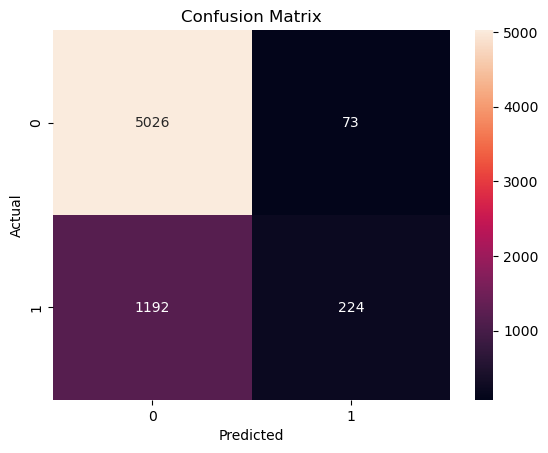

In [26]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [27]:
plt.savefig('confusion_matrix.png')

<Figure size 640x480 with 0 Axes>

In [29]:
feature_importance = pd.DataFrame ({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]})

In [30]:
feature_importance

,feature,coefficient
0,person_age,-6.613237e-08
1,person_income,-4.016729e-05
2,person_emp_length,-2.654139e-08
3,loan_amnt,1.049435e-04
4,loan_int_rate,7.882540e-08
5,loan_percent_income,2.519827e-09
6,cb_person_cred_hist_length,-1.340658e-08


In [32]:
feature_importance['abs_coef'] = feature_importance['coefficient'].abs()

In [33]:
feature_importance = feature_importance.sort_values(
    'abs_coef',
    ascending=False)

In [34]:
feature_importance

,feature,coefficient,abs_coef
3,loan_amnt,1.049435e-04,1.049435e-04
1,person_income,-4.016729e-05,4.016729e-05
4,loan_int_rate,7.882540e-08,7.882540e-08
0,person_age,-6.613237e-08,6.613237e-08
2,person_emp_length,-2.654139e-08,2.654139e-08
6,cb_person_cred_hist_length,-1.340658e-08,1.340658e-08
5,loan_percent_income,2.519827e-09,2.519827e-09


In [35]:
feature_importance.to_csv(
    'feature_importance.csv',
    index=False
)